# Model Comparison

This notebook compares a simple linear baseline model with the previously
evaluated Random Forest classifier for PortScan detection.

The objective is to determine whether the classification task can be solved
effectively using a simpler model or whether a non-linear ensemble model
provides a meaningful advantage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
data_path = Path("../data/processed/portscan_clean.csv")

df = pd.read_csv(data_path)

X = df.drop(columns=["Label"])

y = df["Label"].map({
    "BENIGN": 0,
    "PortScan": 1
})

print("Dataset shape:", df.shape)

Dataset shape: (213777, 79)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [8]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [9]:
y_pred_log = log_model.predict(X_test_scaled)

In [10]:
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Logistic Regression Results")
print("--------------------------------")
print(f"Accuracy : {accuracy_log:.4f}")
print(f"Precision: {precision_log:.4f}")
print(f"Recall   : {recall_log:.4f}")
print(f"F1-score : {f1_log:.4f}")

Logistic Regression Results
--------------------------------
Accuracy : 0.9986
Precision: 0.9982
Recall   : 0.9985
F1-score : 0.9983


In [11]:
cm_log = confusion_matrix(y_test, y_pred_log)

print("Logistic Regression Confusion Matrix:")
print(cm_log)

Logistic Regression Confusion Matrix:
[[24585    32]
 [   28 18111]]


In [12]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_log,
        0.9999
    ],
    "Precision": [
        precision_log,
        1.0000
    ],
    "Recall": [
        recall_log,
        0.9998
    ],
    "F1-score": [
        f1_log,
        0.9999
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.998597,0.998236,0.998456,0.998346
1,Random Forest,0.999900,1.000000,0.999800,0.999900


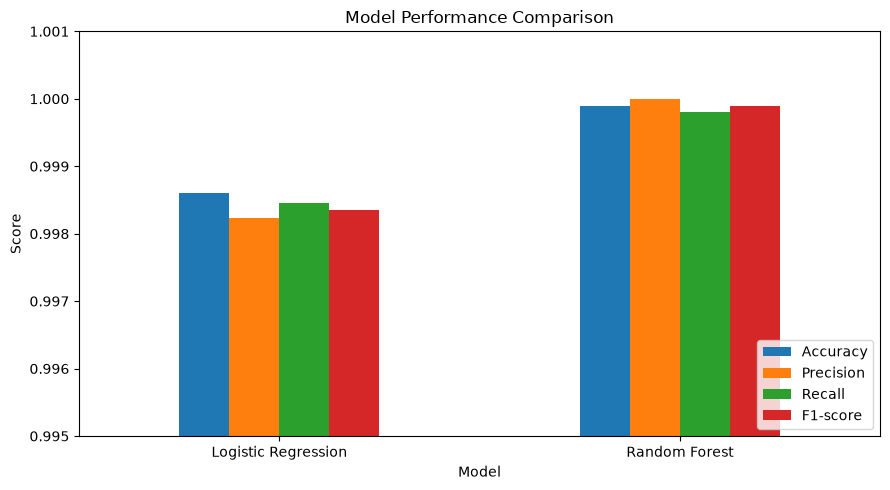

In [13]:
# Visual comparison of model performance

results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0.995, 1.001)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [14]:
from sklearn.tree import DecisionTreeClassifier

# Build Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree training completed!")

Decision Tree training completed!


In [15]:
# Make predictions with Decision Tree
y_pred_dt = dt_model.predict(X_test)

# Evaluate Decision Tree
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("-----------------------------")
print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1-score : {f1_dt:.4f}")

Decision Tree Results
-----------------------------
Accuracy : 0.9999
Precision: 0.9999
Recall   : 0.9998
F1-score : 0.9999


In [16]:
# Final comparison of all three models

results_final = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_log,
        accuracy_dt,
        0.9999
    ],
    "Precision": [
        precision_log,
        precision_dt,
        1.0000
    ],
    "Recall": [
        recall_log,
        recall_dt,
        0.9998
    ],
    "F1-score": [
        f1_log,
        f1_dt,
        0.9999
    ]
})

results_final

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.998597,0.998236,0.998456,0.998346
1,Decision Tree,0.999883,0.999890,0.999835,0.999862
2,Random Forest,0.999900,1.000000,0.999800,0.999900


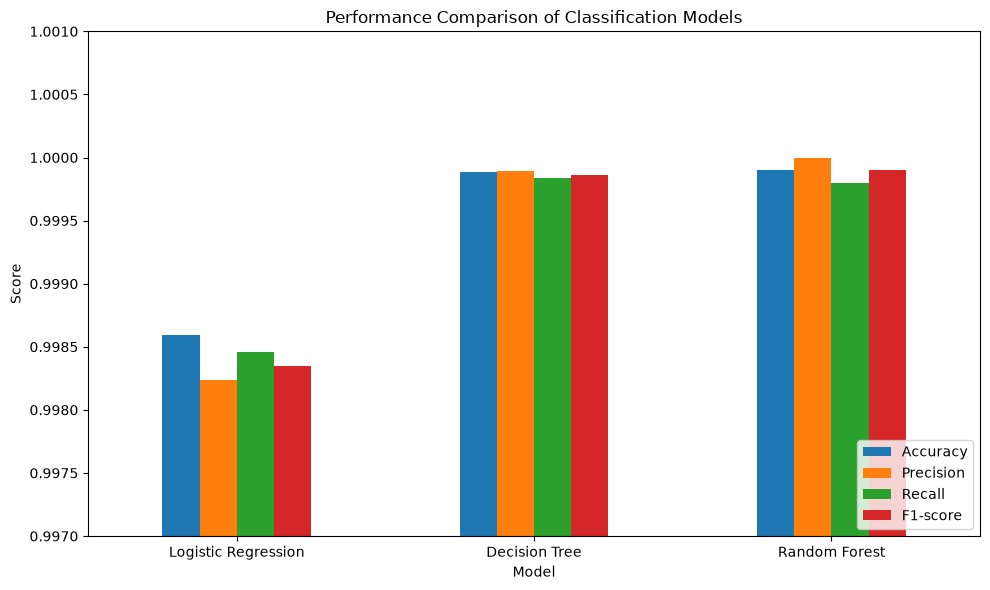

In [17]:
# Visual comparison of all three models

results_final.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Classification Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.997, 1.001)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Model Comparison Analysis

The three classification models achieved very high performance in detecting PortScan traffic.

Logistic Regression achieved an F1-score of approximately 0.9983, demonstrating that even a relatively simple linear model can effectively distinguish between benign and PortScan traffic.

Decision Tree improved the classification performance considerably, achieving an F1-score of approximately 0.9999.

Random Forest provided the strongest overall performance, with an accuracy of 0.9999, precision of 1.0000, recall of 0.9998, and F1-score of 0.9999.

Although Decision Tree achieved a slightly higher recall than Random Forest, Random Forest showed the best overall balance across the evaluation metrics. Therefore, Random Forest was selected as the final model for this network intrusion detection task.